# Final Assignment

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set(rc={'figure.figsize':(15, 9)})
sns.set(font_scale=1.5)

### Part 1

The `food_consumption.csv` dataset from the `data` folder contains data on the several countries' food consumption per food category and their respective CO2 emissions. Load it to a DataFrame named `food` and check its contents.

In [2]:
food = pd.read_csv("data/food_consumption.csv")
food

,country,food_category,consumption,co2_emission
0,Argentina,pork,10.51,37.20
1,Argentina,poultry,38.66,41.53
2,Argentina,beef,55.48,1712.00
3,Argentina,lamb_goat,1.56,54.63
4,Argentina,fish,4.36,6.96
...,...,...,...,...
1425,Bangladesh,dairy,21.91,31.21
1426,Bangladesh,wheat,17.47,3.33
1427,Bangladesh,rice,171.73,219.76
1428,Bangladesh,soybeans,0.61,0.27


1. Use the `.describe()` method on the `food` DataFrame to produce descriptive statistics about the `consumption` metric for each class in the `food_category` variable. **Which `food_category` has the highest median value of `food_consumption`?**

In [3]:
food.groupby("food_category")["consumption"].describe().sort_values("mean")
#The highest median value of food consuption is in the dairy products

,count,mean,std,min,25%,50%,75%,max
food_category,,,,,,,,
soybeans,130.0,0.860538,2.083336,0.00,0.0100,0.075,0.6400,16.95
lamb_goat,130.0,2.600154,3.665252,0.00,0.5600,1.325,3.1025,21.12
nuts,130.0,4.137231,3.372817,0.18,1.8050,3.495,5.6100,23.03
eggs,130.0,8.163769,5.032582,0.16,3.9450,8.420,12.3125,19.15
beef,130.0,12.123385,9.654140,0.78,4.9975,8.285,17.9400,55.48
pork,130.0,16.123692,15.717646,0.00,2.0900,10.355,28.2275,67.11
fish,130.0,17.287077,19.013508,0.24,6.0250,13.950,21.8525,179.71
poultry,130.0,21.219231,14.571980,0.47,10.9100,19.855,29.7475,62.50
rice,130.0,29.375154,37.324471,0.95,4.7200,11.875,43.4425,171.73


2. In a single chart, plot one boxplot for each `food_category` (11 in total) using the variable `co2_emission` as the metric. **By looking at the chart, which `food_category` has the highest interquartile range (IQR)?**

Text(0.5, 1.0, 'co2 emission per food')

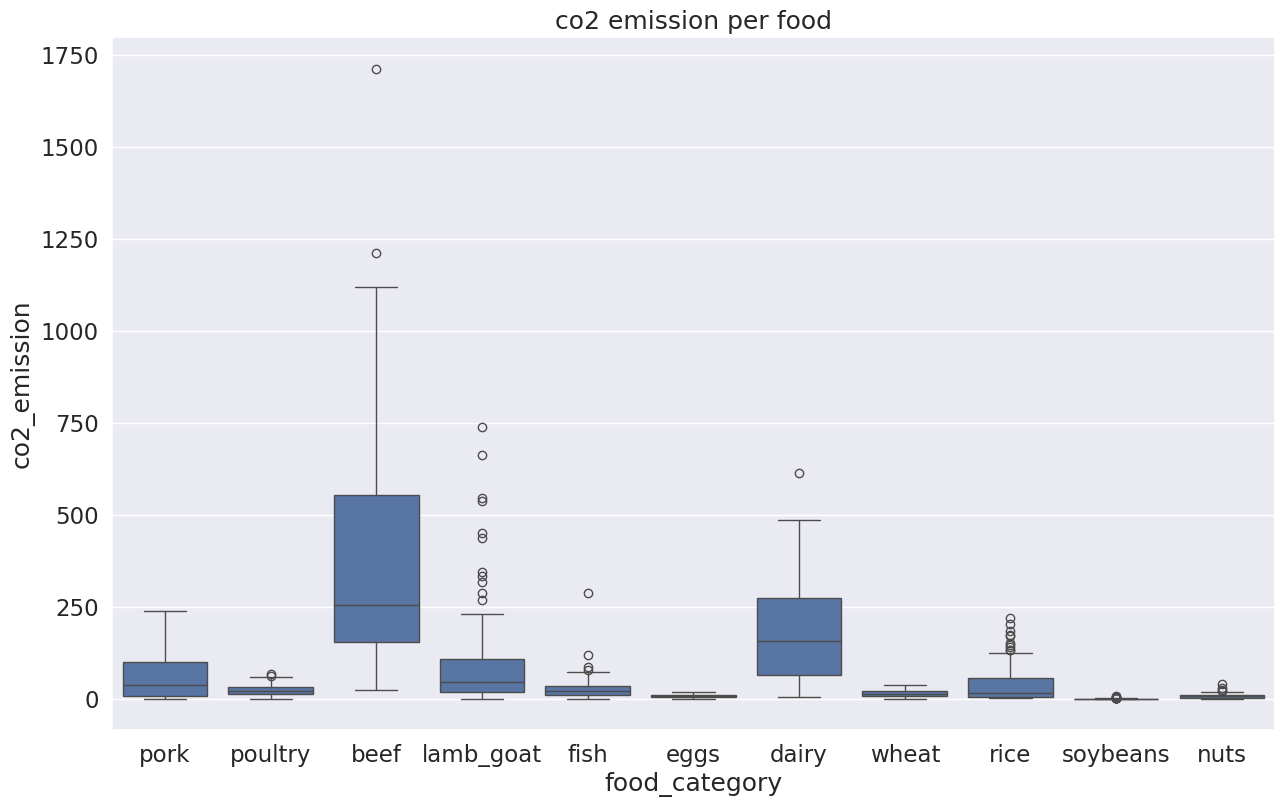

In [4]:
sns.boxplot(x="food_category",y= "co2_emission", data = food).set_title("co2 emission per food")
#the food that has the biggest IQR is beef

3. Looking at the chart from the previous question, which is the `food_category` with the highest median `co2_emission` value?

In [9]:
#from a database of 1430 rows we can observe that the beef has the highest
#average co2 emission compared to other food categories
foodMean = food.groupby("food_category")["consumption"].describe().sort_values("mean", ascending=False)
print(foodMean)

               count        mean        std   min      25%      50%       75%  \
food_category                                                                   
dairy          130.0  125.774692  93.327721  3.04  45.7925  110.975  192.7150   
wheat          130.0   71.549538  44.191318  2.74  37.0450   69.420  103.3725   
rice           130.0   29.375154  37.324471  0.95   4.7200   11.875   43.4425   
poultry        130.0   21.219231  14.571980  0.47  10.9100   19.855   29.7475   
fish           130.0   17.287077  19.013508  0.24   6.0250   13.950   21.8525   
pork           130.0   16.123692  15.717646  0.00   2.0900   10.355   28.2275   
beef           130.0   12.123385   9.654140  0.78   4.9975    8.285   17.9400   
eggs           130.0    8.163769   5.032582  0.16   3.9450    8.420   12.3125   
nuts           130.0    4.137231   3.372817  0.18   1.8050    3.495    5.6100   
lamb_goat      130.0    2.600154   3.665252  0.00   0.5600    1.325    3.1025   
soybeans       130.0    0.86

4. Consider the `consumption` of "poultry" and "fish" across all available `countries`; looking at the table from question 1, the average of poultry consumption (21.22) seems to be higher than that of fish consumption (17.29), but is this difference statistically significant? Create a permutation test in order to assess the null hypothesis that there is no difference between the two means. **Do you accept or reject the null hypothesis?** Explain why.

mu_diff: 3.93
p-value:  0.029501475073753686
p-value <= alpha | the observed result is statistically significant | H0 rejected


'\nFrom the test case we can observe how the p-value is almost always surpassing the 5% treshold, \nsometimes even managing to surpass the 10%, meaning that there is a difference between the two food consumption\n'

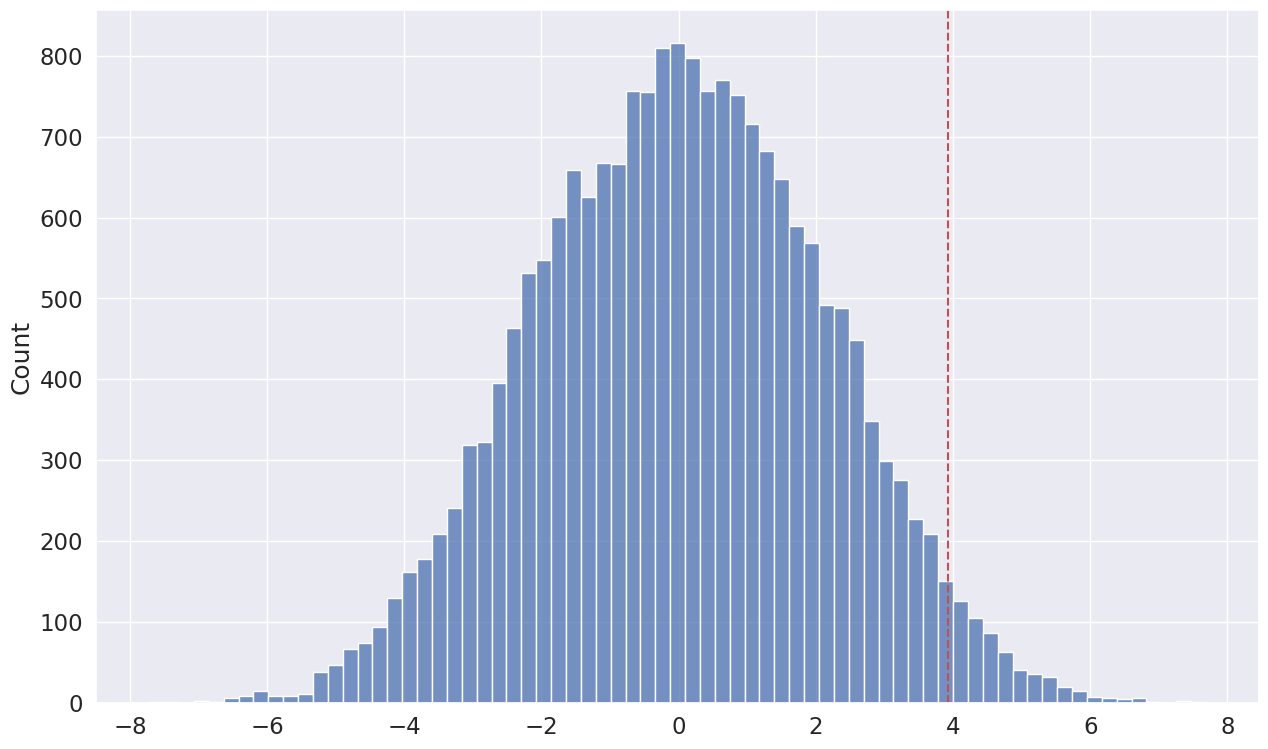

In [10]:
n = 20000
alpha = 0.05
muDiff = round(foodMean['mean']['poultry']-foodMean['mean']['fish'], 3)
muDiffSamples = []

fish = food[food['food_category'] == 'fish']
poultry = food[food['food_category'] == 'poultry']
#Joining the two databases
fishAndPoultryDB = pd.concat([fish, poultry])

for n in range(n):
    sample1 = fishAndPoultryDB.sample(frac=0.5, replace=False)
    ix2 = set(fishAndPoultryDB.index) - set(sample1.index)
    sample2 = fishAndPoultryDB.loc[list(ix2)]
    muDiffTemp = np.mean(sample1['consumption']) - np.mean(sample2['consumption'])
    muDiffSamples.append(muDiffTemp)

sns.histplot(muDiffSamples)
plt.axvline(muDiff, 0, 1, color='r', linestyle='--')
# plt.show()
print('mu_diff:', round(muDiff, 2))

p_value = sum(muDiffSamples > muDiff) / n
print('p-value: ', p_value)
if p_value <= alpha:
    print('p-value <= alpha | the observed result is statistically significant | H0 rejected')
else:
    print('p-value > alpha | the observed result is not statistically significant | H0 accepted')
'''
From the test case we can observe how the p-value is almost always surpassing the 5% treshold,
sometimes even managing to surpass the 10%, meaning that there is a difference between the two food consumption
'''

### Part 2

The `distributions.csv` dataset from the `data` folder contains data drawn from 6 probability distributions – one per column. Load it to a DataFrame named `distributions` and check its contents.

In [12]:
distributions = pd.read_csv("data/distributions.csv")
distributions

,distribution_1,distribution_2,distribution_3,distribution_4,distribution_5,distribution_6,distribution_7
0,False,100.004134,3.608307,890,1,-34,0.563827
1,False,100.008868,5.785856,897,1,-35,1.441859
2,False,100.004402,4.785344,898,3,-37,0.347664
3,False,100.000589,5.712047,890,0,-34,3.039330
4,False,100.017889,4.240379,898,1,-35,0.089587
...,...,...,...,...,...,...,...
995,False,100.017274,5.734047,903,2,-33,0.096619
996,False,100.012275,4.583540,891,2,-31,0.726007
997,False,100.000855,3.999458,888,1,-31,0.228308
998,False,100.005987,4.169784,882,1,-35,0.436532


1. Use the `.describe()` and `info()` methods on the `distributions` DataFrame to produce some preliminary information about each column. **What is the data type of each column?**

In [13]:
print(distributions.describe())
print(distributions.info())
#distribution_1 is boolean
#distribution 2 3 and 7 are float
#distribution 4 5 6 are integers

       distribution_2  distribution_3  distribution_4  distribution_5  \
count     1000.000000     1000.000000     1000.000000     1000.000000   
mean       100.000263        3.462706      899.630000        1.192000   
std          0.010155        1.466874        9.729531        1.091938   
min         99.961668        1.002417      865.000000        0.000000   
25%         99.993916        2.223423      893.000000        0.000000   
50%        100.000598        3.426250      900.000000        1.000000   
75%        100.007031        4.679788      906.000000        2.000000   
max        100.034052        5.997595      929.000000        6.000000   

       distribution_6  distribution_7  
count     1000.000000     1000.000000  
mean       -34.539000        0.513223  
std          2.889087        0.497540  
min        -39.000000        0.000033  
25%        -37.000000        0.141789  
50%        -34.000000        0.362279  
75%        -32.000000        0.735851  
max        -30.000000 

2. Loop through each column of `distributions` and for each column produce a plot to show the distribution.

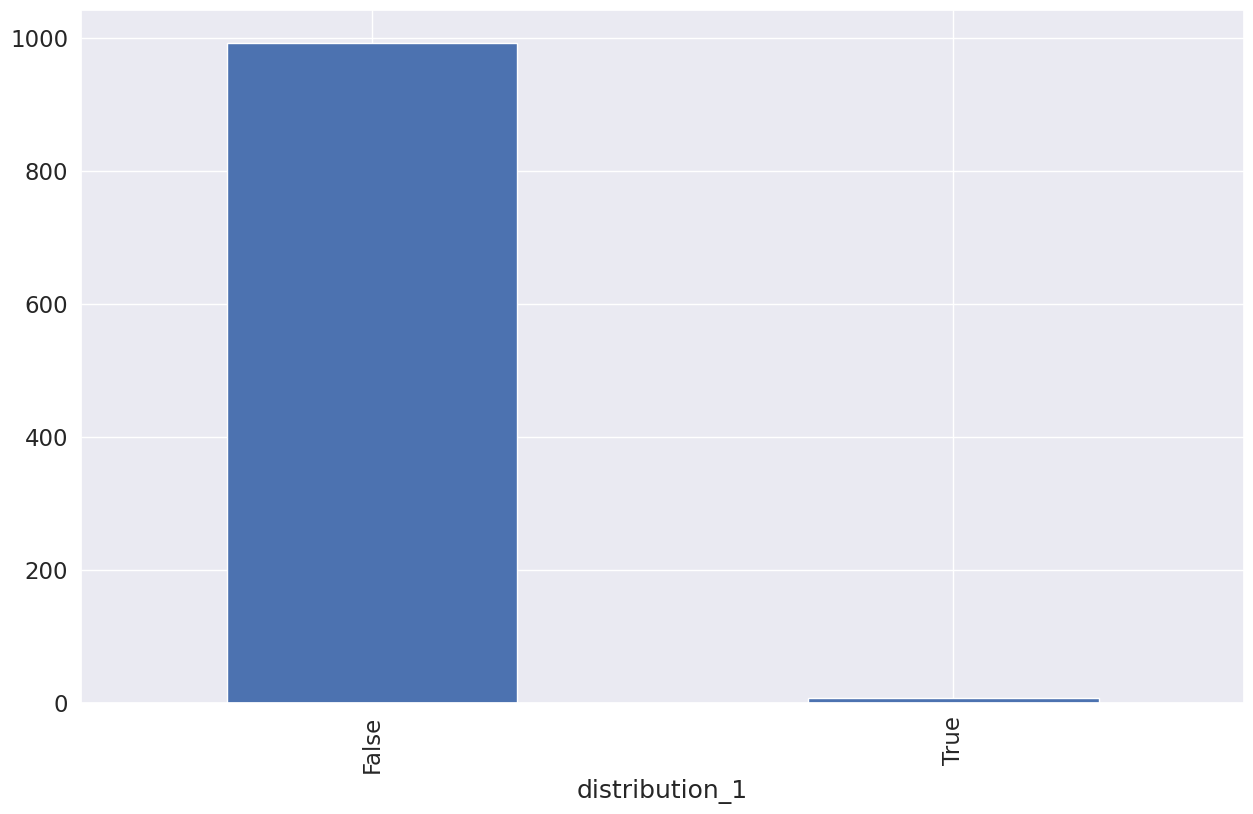

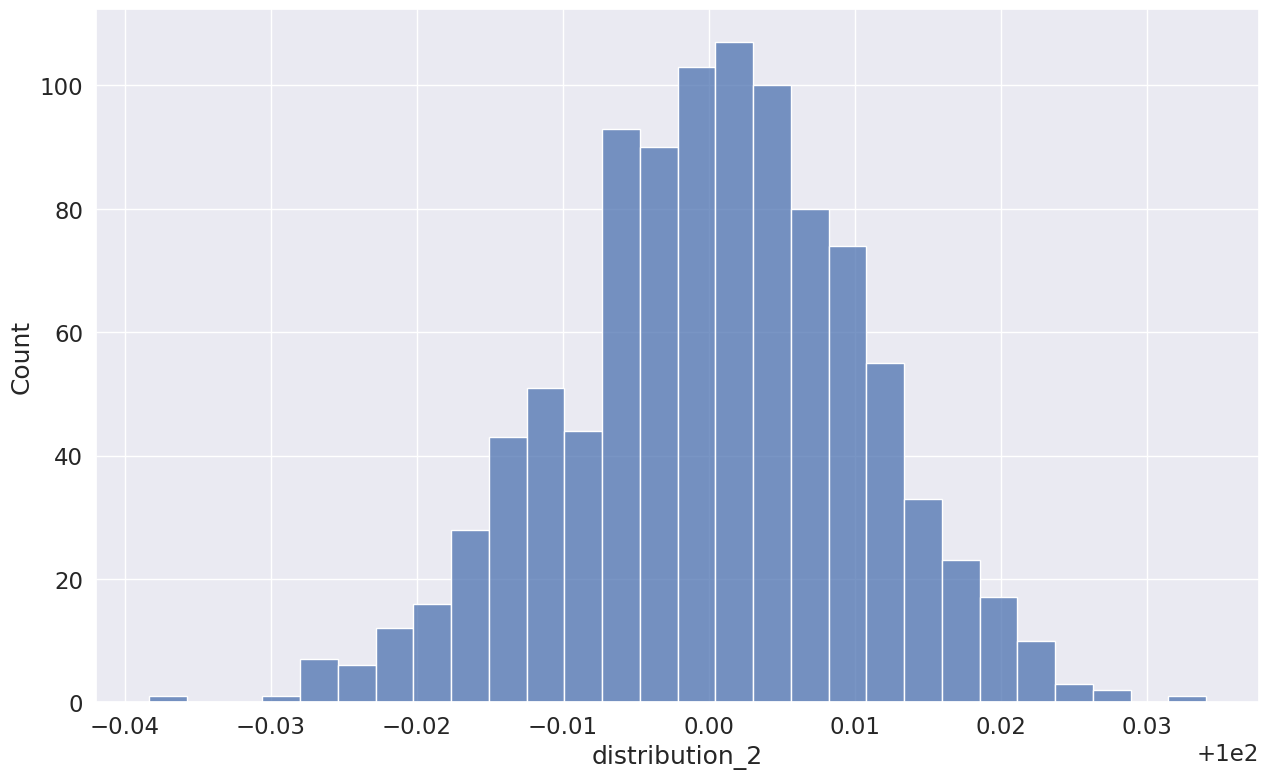

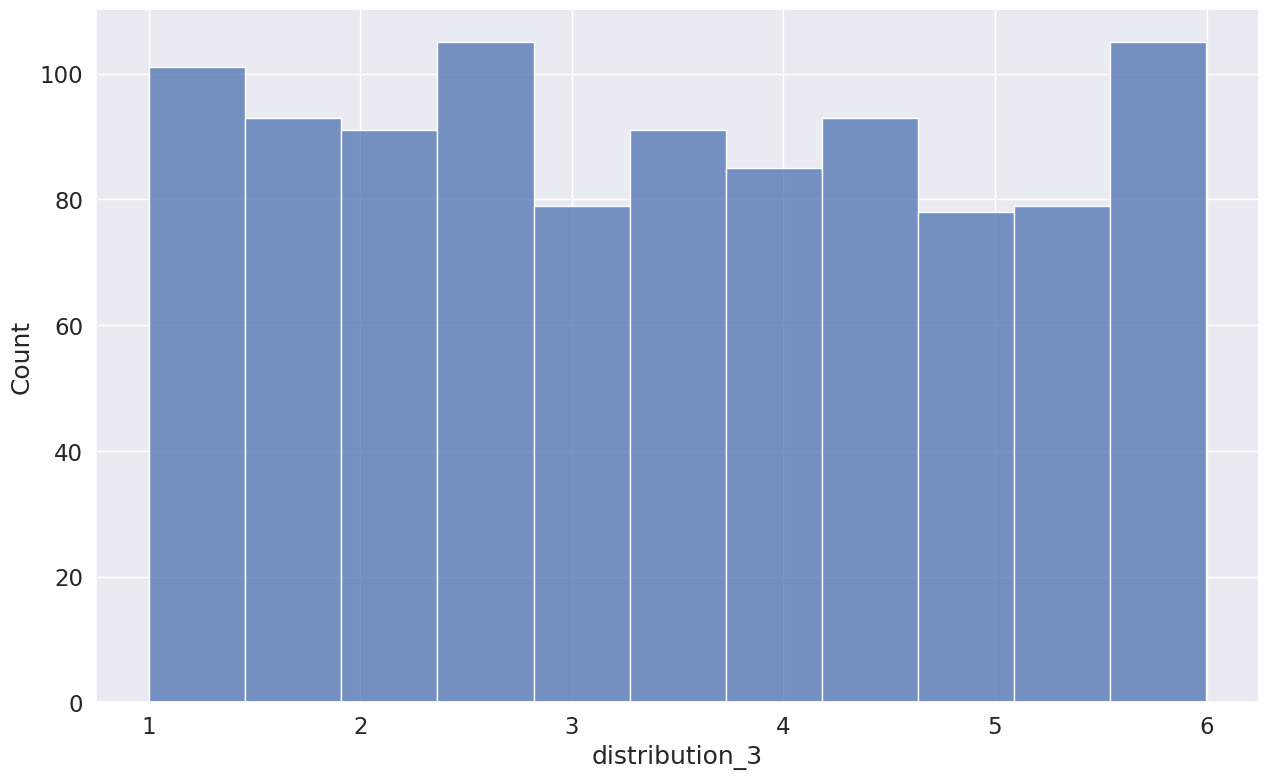

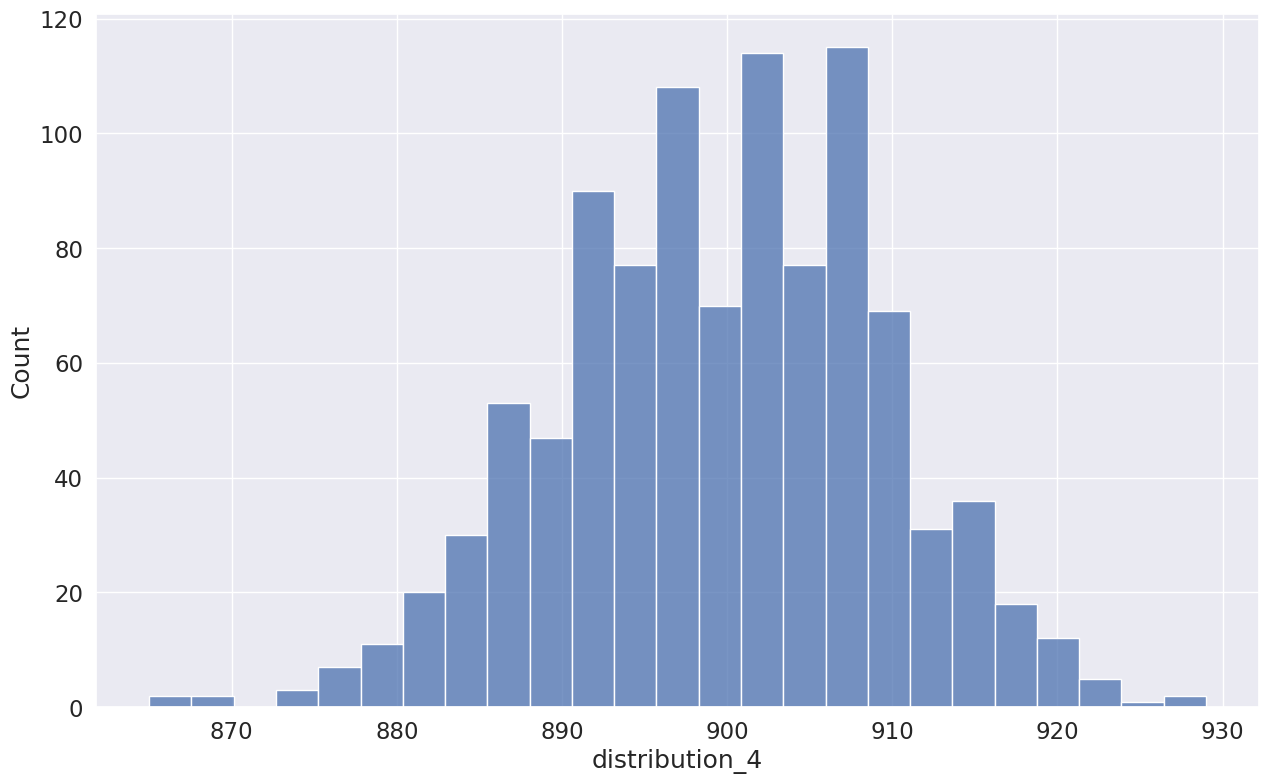

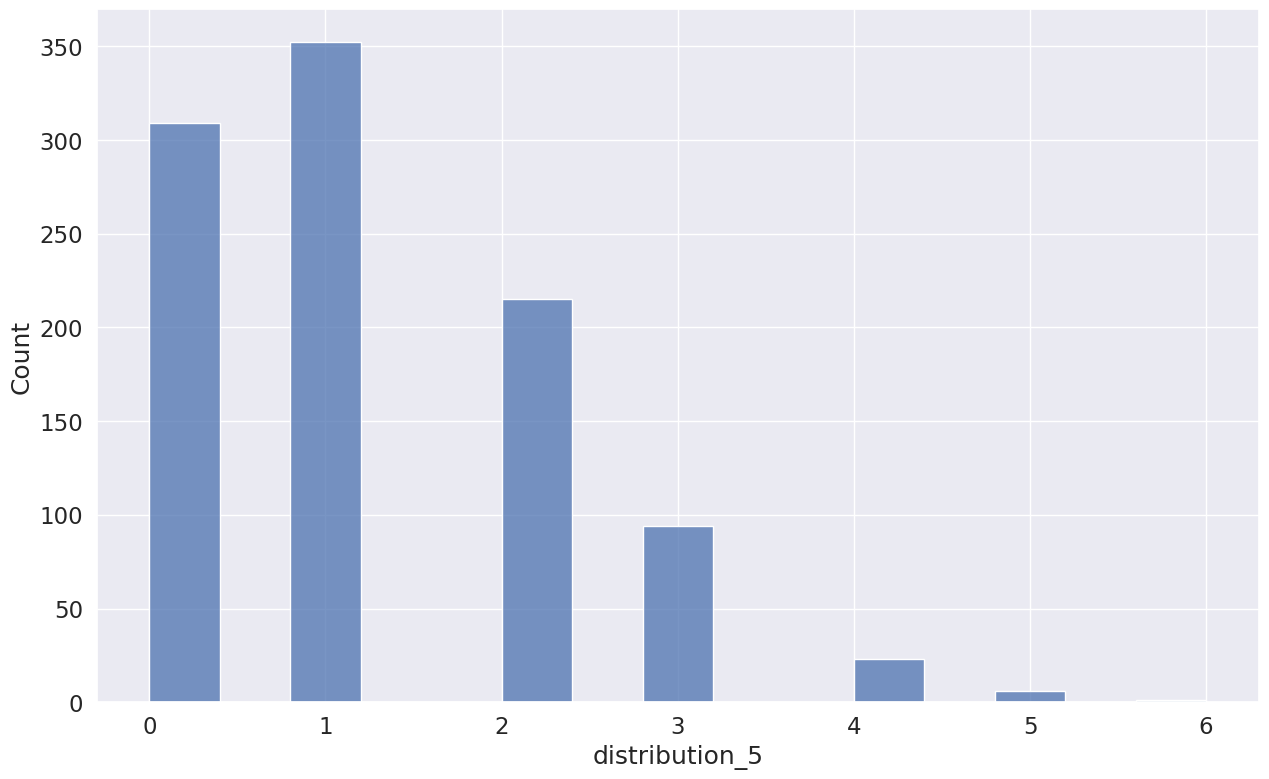

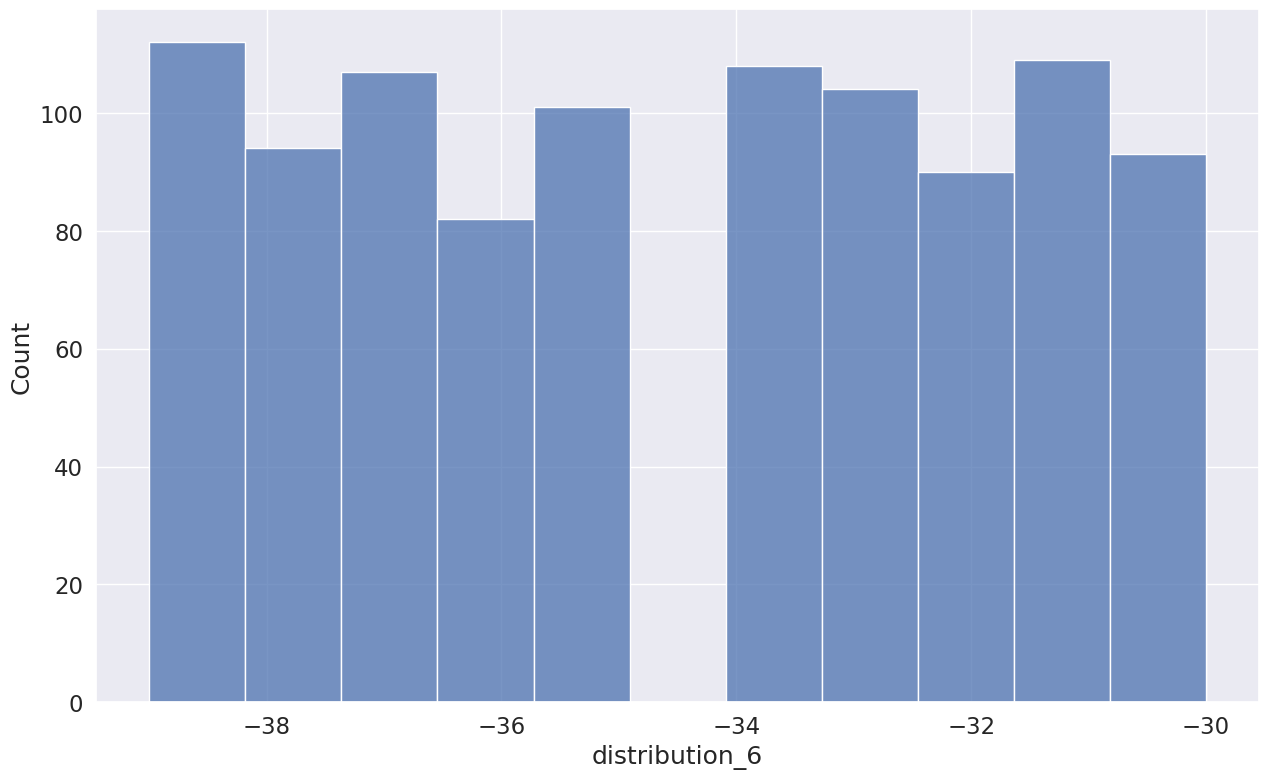

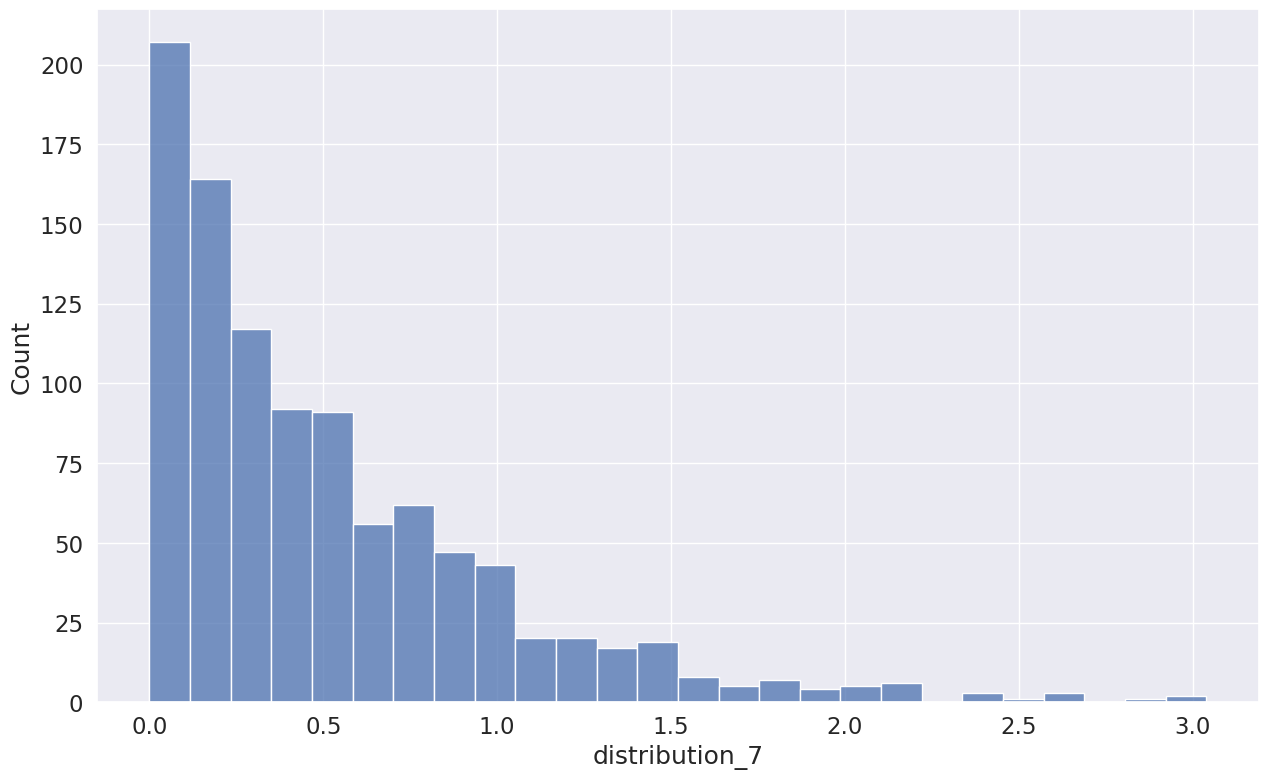

In [45]:
for col in distributions.columns:
    if distributions[col].dtype == bool:
      distributions[col].value_counts().plot(kind='bar')
    else:
      sns.histplot(x=col ,data=distributions)
    plt.show()
    plt.close()

3. Each column of the `distributions` dataframe contains data drawn from a different distribution. **Associate each column to its probability distribution.** This is the list of the probability distributions used (one for each column):
    - Bernoulli
    - Binomial
    - Continuous Uniform
    - Gaussian (Normal)
    - Discrete Uniform
    - Poisson
    - Exponential (this was not explain in classroom, go by exclusion)

In [ ]:
Bernoulli - distribution_1
Binomial - distribution_2
Continuous Uniform - distribution_3
Gaussian (Normal) - distribution_4
Discrete Uniform - distribution_6
Poisson - distribution_5
Exponential - distribution_7